In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('c.csv')

# Convert created_at to datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Basic data info
print("Dataset Overview:")
print(f"Total sessions: {len(df)}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")
print(f"Unique students: {df['student_id'].nunique()}")
print(f"Game modes: {df['game_mode'].value_counts()}")
print("\n" + "="*50 + "\n")

Dataset Overview:
Total sessions: 261
Date range: 2025-06-26 07:55:26 to 2025-06-26 08:30:15
Unique students: 16
Game modes: game_mode
practice    130
computer     67
pvp          64
Name: count, dtype: int64




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


PRACTICE MODE ANALYSIS
Total practice sessions: 130
Unique students in practice: 15

Practice Mode Statistics:
Average time per session: 89.9 seconds
std time per session: 44.8 seconds
Average time per question: 9.0 seconds
std time per question: 4.5 seconds
Average accuracy: 67.82%
std accuracy: 21.01%
Average attempts per question: 1.7
std attempts per question: 0.6
Average wrong attempts per session: 6.5
std wrong attempts per session: 6.2
Total sessions with all questions correct: 17


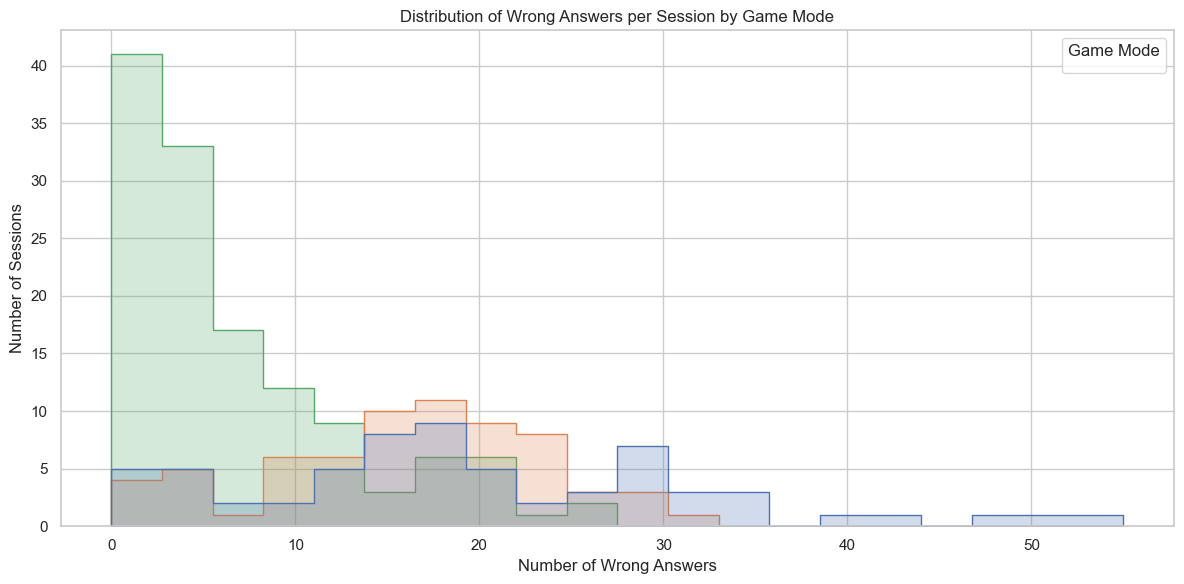

In [2]:
# =============================================================================
# PRACTICE MODE ANALYSIS
# =============================================================================
practice_df = df[df['game_mode'] == 'practice'].copy()

print("PRACTICE MODE ANALYSIS")
print("="*30)
print(f"Total practice sessions: {len(practice_df)}")
print(f"Unique students in practice: {practice_df['student_id'].nunique()}")

# Practice mode metrics
#practice_df['accuracy'] = practice_df['correct_answers'] / (practice_df['correct_answers'] + practice_df['wrong_answers'])
practice_df['accuracy'] = practice_df['correct_answers'] / (practice_df['correct_answers'] + practice_df['wrong_answers'])

practice_df['time_per_question'] = practice_df['time_taken'] / practice_df['total_questions']
practice_df['attempts_per_question'] = (practice_df['correct_answers'] + practice_df['wrong_answers']) / practice_df['total_questions']



print(f"\nPractice Mode Statistics:")
print(f"Average time per session: {practice_df['time_taken'].mean():.1f} seconds")
print(f"std time per session: {practice_df['time_taken'].std():.1f} seconds")
print(f"Average time per question: {practice_df['time_per_question'].mean():.1f} seconds")
print(f"std time per question: {practice_df['time_per_question'].std():.1f} seconds")
print(f"Average accuracy: {practice_df['accuracy'].mean():.2%}")
print(f"std accuracy: {practice_df['accuracy'].std():.2%}")
print(f"Average attempts per question: {practice_df['attempts_per_question'].mean():.1f}")
print(f"std attempts per question: {practice_df['attempts_per_question'].std():.1f}")
print(f"Average wrong attempts per session: {practice_df['wrong_answers'].mean():.1f}")
print(f"std wrong attempts per session: {practice_df['wrong_answers'].std():.1f}")


all_corect_sessions = practice_df[practice_df['wrong_answers'] == 0]
print(f"Total sessions with all questions correct: {len(all_corect_sessions)}")


sns.set(style="whitegrid")

# Plot the distribution of wrong answers
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="wrong_answers", hue="game_mode", element="step", stat="count", common_norm=False, bins=20)
plt.title("Distribution of Wrong Answers per Session by Game Mode")
plt.xlabel("Number of Wrong Answers")
plt.ylabel("Number of Sessions")
plt.legend(title="Game Mode")
plt.tight_layout()
plt.show()



In [4]:
# =============================================================================
# COMPUTER MODE ANALYSIS
# =============================================================================
computer_df = df[df['game_mode'] == 'computer'].copy()

print(f"\n\nCOMPUTER MODE ANALYSIS")
print("="*30)
print(f"Total computer sessions: {len(computer_df)}")
print(f"Unique students in computer mode: {computer_df['student_id'].nunique()}")

# Computer mode metrics
computer_df['questions_per_second'] = computer_df['total_questions'] / computer_df['time_taken']
#computer_df['accuracy'] = computer_df['correct_answers'] / computer_df['total_questions']
computer_df['accuracy'] = computer_df['correct_answers'] / ( computer_df['correct_answers'] + computer_df['wrong_answers'] )
win_rate_computer = (computer_df['winner'] == 't').mean()
atempts_per_question_computer = (computer_df['correct_answers'] + computer_df['wrong_answers']) / computer_df['total_questions']  
 

print(f"\nComputer Mode Statistics:")
print(f"Average time per session: {computer_df['time_taken'].mean():.1f} seconds")
print(f"Average questions shown: {computer_df['total_questions'].mean():.1f}")
print(f"Average questions per second: {computer_df['questions_per_second'].mean():.2f}")
print(f"Average student accuracy: {computer_df['accuracy'].mean():.2%}")
print(f"Average attempts per question: {atempts_per_question_computer.mean():.1f}")
print(f"Student win rate vs computer: {win_rate_computer:.2%}")
print(f"Average points when winning: {computer_df[computer_df['winner'] == 't']['points'].mean():.1f}")




COMPUTER MODE ANALYSIS
Total computer sessions: 67
Unique students in computer mode: 15

Computer Mode Statistics:
Average time per session: 44.5 seconds
Average questions shown: 14.8
Average questions per second: 0.65
Average student accuracy: 41.57%
Average attempts per question: 2.3
Student win rate vs computer: 97.01%
Average points when winning: 4.9


In [5]:
# =============================================================================
# PVP MODE ANALYSIS
# =============================================================================
pvp_df = df[df['game_mode'] == 'pvp'].copy()

print(f"\n\nPVP MODE ANALYSIS")
print("="*30)
print(f"Total PVP sessions: {len(pvp_df)}")
print(f"Unique students in PVP: {pvp_df['student_id'].nunique()}")

# PVP metrics
pvp_df['questions_per_second'] = pvp_df['total_questions'] / pvp_df['time_taken']
pvp_df['accuracy'] = pvp_df['correct_answers'] / (pvp_df['correct_answers'] + pvp_df['wrong_answers'])
atempts_per_question_pvp = (pvp_df['correct_answers'] + pvp_df['wrong_answers']) / pvp_df['total_questions']
pvp_wins = pvp_df[pvp_df['winner'] == 't']
pvp_losses = pvp_df[pvp_df['winner'] == 'f']

print(f"\nPVP Mode Statistics:")
print(f"Average time per session: {pvp_df['time_taken'].mean():.1f} seconds")
print(f"Average questions shown: {pvp_df['total_questions'].mean():.1f}")
print(f"Average questions per second: {pvp_df['questions_per_second'].mean():.2f}")
print(f"Average accuracy: {pvp_df['accuracy'].mean():.2%}")
print(f"Average attempts per question: {atempts_per_question_pvp.mean():.1f}")
print(f"Win rate: {(pvp_df['winner'] == 't').mean():.2%}")

print(f"\nPVP Winners vs Losers:")
print(f"Winners - Avg correct: {pvp_wins['correct_answers'].mean():.1f}, Avg accuracy: {pvp_wins['accuracy'].mean():.2%}")
print(f"Losers - Avg correct: {pvp_losses['correct_answers'].mean():.1f}, Avg accuracy: {pvp_losses['accuracy'].mean():.2%}")




PVP MODE ANALYSIS
Total PVP sessions: 64
Unique students in PVP: 16

PVP Mode Statistics:
Average time per session: 102.1 seconds
Average questions shown: 31.7
Average questions per second: 0.34
Average accuracy: 40.84%
Average attempts per question: 1.3
Win rate: 65.62%

PVP Winners vs Losers:
Winners - Avg correct: 16.5, Avg accuracy: 38.92%
Losers - Avg correct: 12.7, Avg accuracy: 44.43%


In [6]:
# =============================================================================
# COMPARATIVE ANALYSIS
# =============================================================================
print(f"\n\nCOMPARATIVE ANALYSIS")
print("="*30)

# Time analysis
print("Average Session Duration by Mode:")
for mode in ['practice', 'computer', 'pvp']:
    avg_time = df[df['game_mode'] == mode]['time_taken'].mean()
    print(f"{mode.capitalize()}: {avg_time:.1f} seconds")

# Performance comparison
print(f"\nAccuracy Comparison:")
practice_acc = practice_df['accuracy'].mean()
computer_acc = computer_df['accuracy'].mean()
pvp_acc = pvp_df['accuracy'].mean()

print(f"Practice: {practice_acc:.2%}")
print(f"Computer: {computer_acc:.2%}")
print(f"PVP: {pvp_acc:.2%}")

# =============================================================================
# STUDENT PERFORMANCE ANALYSIS
# =============================================================================
print(f"\n\nSTUDENT PERFORMANCE ANALYSIS")
print("="*35)

# Student activity by mode
student_activity = df.groupby(['student_id', 'game_mode']).size().unstack(fill_value=0)
print("Student Activity by Mode:")
print(student_activity.describe())

# Top performers
print(f"\nTop 5 Students by Practice Accuracy:")
if len(practice_df) > 0:
    practice_student_stats = practice_df.groupby('student_id').agg({
        'accuracy': 'mean',
        'session_id': 'count',
        'time_per_question': 'mean'
    }).round(3)
    practice_student_stats.columns = ['avg_accuracy', 'sessions', 'avg_time_per_q']
    top_practice = practice_student_stats.sort_values('avg_accuracy', ascending=False).head()
    print(top_practice)

print(f"\nTop 5 Students by Computer Mode Win Rate:")
if len(computer_df) > 0:
    computer_student_stats = computer_df.groupby('student_id').agg({
        'winner': lambda x: (x == 't').mean(),
        'session_id': 'count',
        'accuracy': 'mean'
    }).round(3)
    computer_student_stats.columns = ['win_rate', 'sessions', 'avg_accuracy']
    top_computer = computer_student_stats.sort_values('win_rate', ascending=False).head()
    print(top_computer)




COMPARATIVE ANALYSIS
Average Session Duration by Mode:
Practice: 89.9 seconds
Computer: 44.5 seconds
Pvp: 102.1 seconds

Accuracy Comparison:
Practice: 67.70%
Computer: 41.57%
PVP: 40.84%


STUDENT PERFORMANCE ANALYSIS
Student Activity by Mode:
game_mode  computer   practice        pvp
count      16.00000  16.000000  16.000000
mean        4.18750   8.125000   4.000000
std         2.50915   3.159641   1.788854
min         0.00000   0.000000   1.000000
25%         2.75000   6.750000   2.750000
50%         3.50000   8.000000   4.000000
75%         7.00000  10.000000   5.000000
max         7.00000  14.000000   7.000000

Top 5 Students by Practice Accuracy:
            avg_accuracy  sessions  avg_time_per_q
student_id                                        
39                 0.912         6          20.700
30                 0.899         6           5.817
49                 0.865         9           8.244
36                 0.745         7          10.686
43                 0.739       

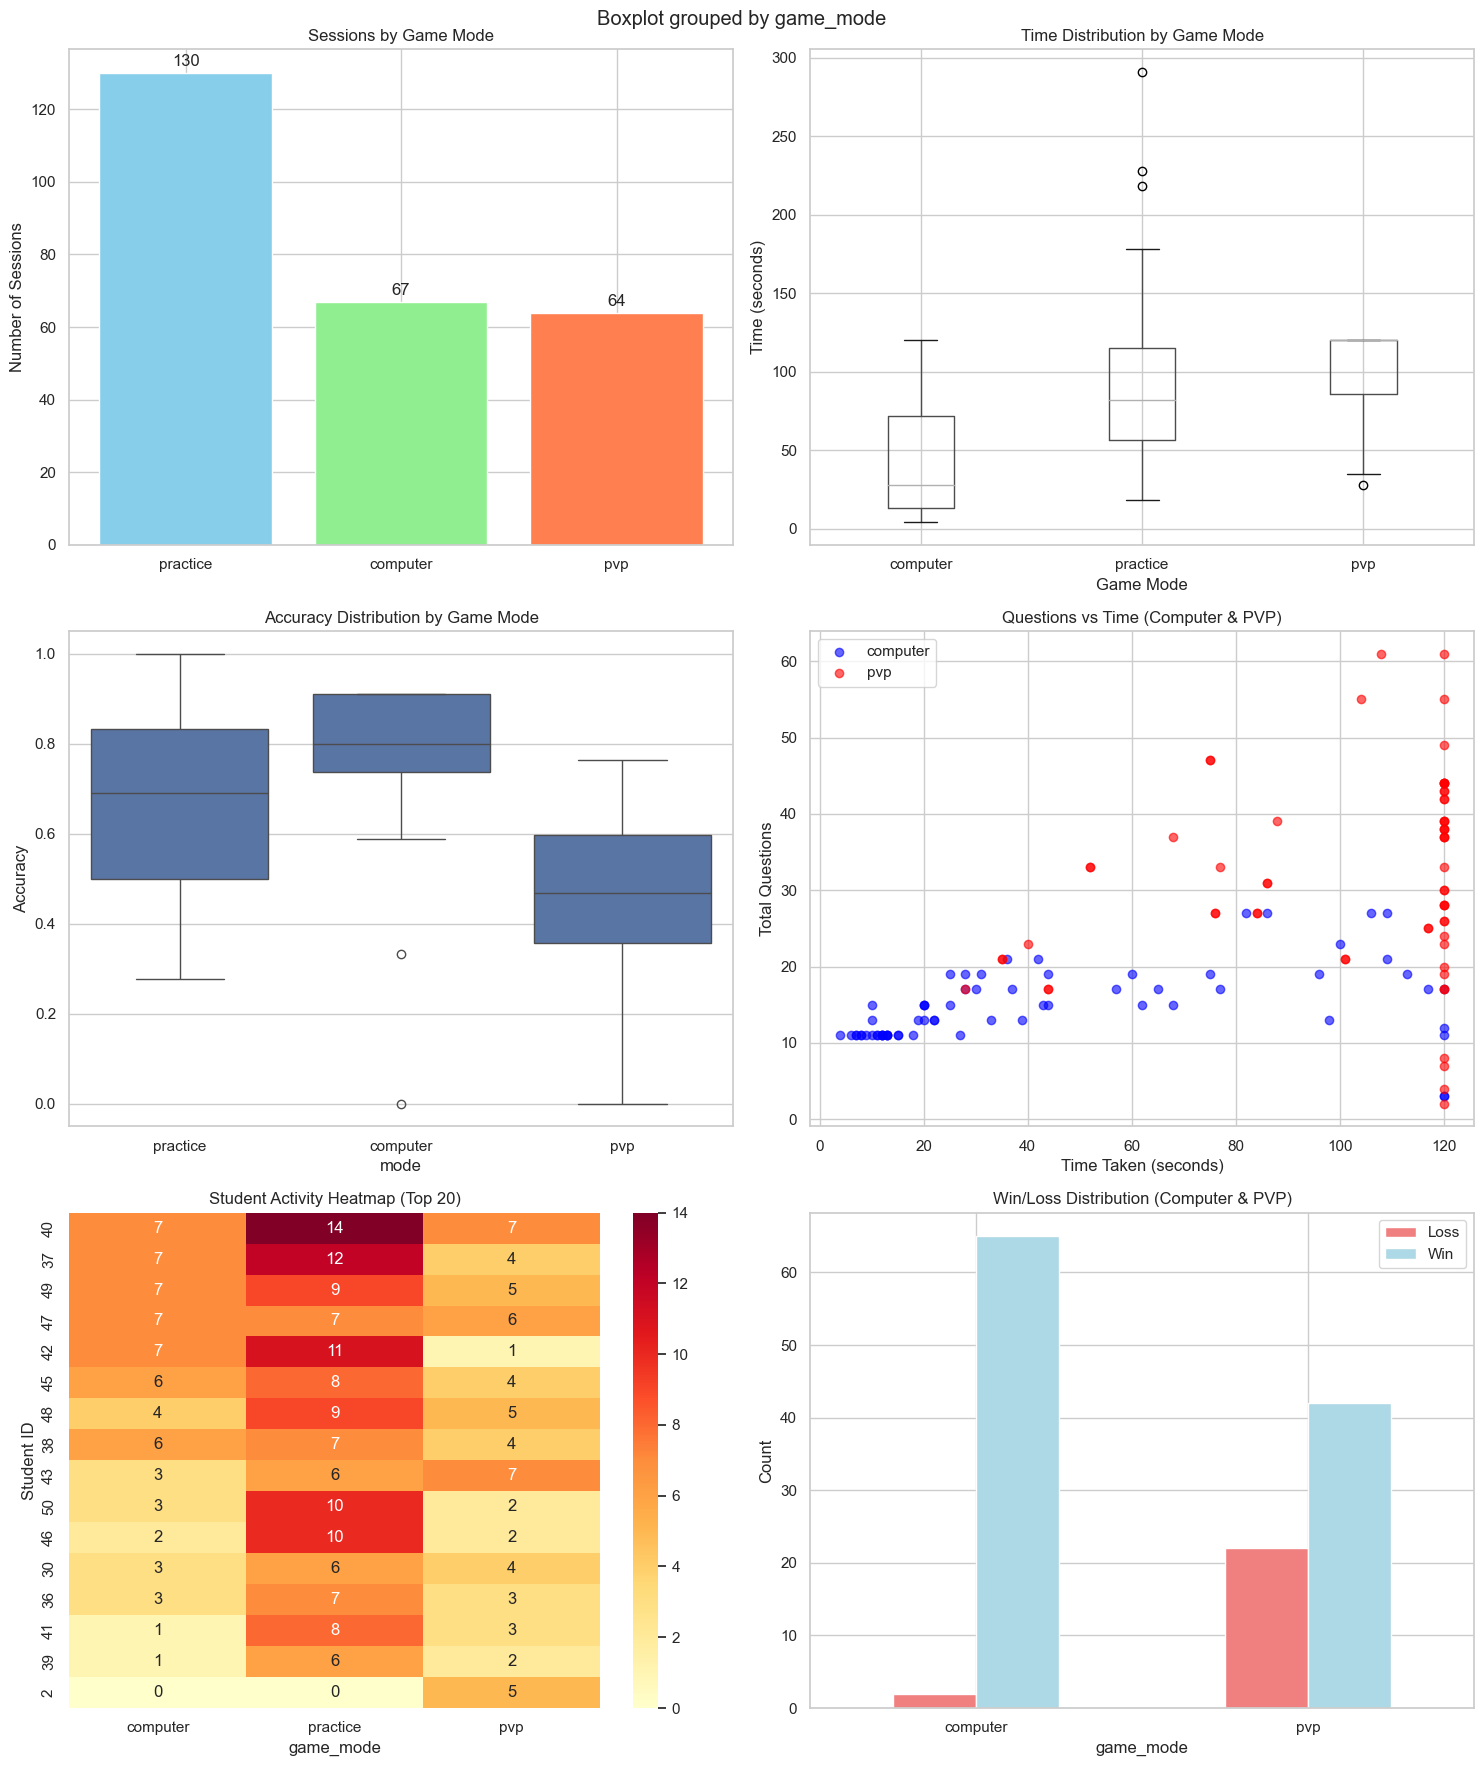

In [7]:
# =============================================================================
# VISUALIZATIONS
# =============================================================================

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Game Sessions Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Session count by mode
mode_counts = df['game_mode'].value_counts()
axes[0, 0].bar(mode_counts.index, mode_counts.values, color=['skyblue', 'lightgreen', 'coral'])
axes[0, 0].set_title('Sessions by Game Mode')
axes[0, 0].set_ylabel('Number of Sessions')
for i, v in enumerate(mode_counts.values):
    axes[0, 0].text(i, v + 1, str(v), ha='center', va='bottom')

# 2. Time distribution by mode
df.boxplot(column='time_taken', by='game_mode', ax=axes[0, 1])
axes[0, 1].set_title('Time Distribution by Game Mode')
axes[0, 1].set_ylabel('Time (seconds)')
axes[0, 1].set_xlabel('Game Mode')

# 3. Accuracy comparison
accuracy_data = []
for mode in ['practice', 'computer', 'pvp']:
    mode_df = df[df['game_mode'] == mode].copy()
    if mode == 'practice':
        mode_df['accuracy'] = mode_df['correct_answers'] / (mode_df['correct_answers'] + mode_df['wrong_answers'])
    else:
        mode_df['accuracy'] = mode_df['correct_answers'] / mode_df['total_questions']
    accuracy_data.extend([(mode, acc) for acc in mode_df['accuracy']])

accuracy_df = pd.DataFrame(accuracy_data, columns=['mode', 'accuracy'])
sns.boxplot(data=accuracy_df, x='mode', y='accuracy', ax=axes[1, 0])
axes[1, 0].set_title('Accuracy Distribution by Game Mode')
axes[1, 0].set_ylabel('Accuracy')

# 4. Questions vs Time scatter (Computer and PVP)
timed_modes = df[df['game_mode'].isin(['computer', 'pvp'])]
colors = {'computer': 'blue', 'pvp': 'red'}
for mode in ['computer', 'pvp']:
    mode_data = timed_modes[timed_modes['game_mode'] == mode]
    axes[1, 1].scatter(mode_data['time_taken'], mode_data['total_questions'], 
                      alpha=0.6, label=mode, color=colors[mode])
axes[1, 1].set_xlabel('Time Taken (seconds)')
axes[1, 1].set_ylabel('Total Questions')
axes[1, 1].set_title('Questions vs Time (Computer & PVP)')
axes[1, 1].legend()

# 5. Student activity heatmap
if len(student_activity) > 0:
    # Show top 20 most active students
    top_students = student_activity.sum(axis=1).nlargest(20).index
    student_subset = student_activity.loc[top_students]
    
    sns.heatmap(student_subset, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2, 0])
    axes[2, 0].set_title('Student Activity Heatmap (Top 20)')
    axes[2, 0].set_ylabel('Student ID')

# 6. Win/Loss analysis for competitive modes
competitive_df = df[df['game_mode'].isin(['computer', 'pvp'])]
win_loss_data = competitive_df.groupby(['game_mode', 'winner']).size().unstack(fill_value=0)
win_loss_data.plot(kind='bar', ax=axes[2, 1], color=['lightcoral', 'lightblue'])
axes[2, 1].set_title('Win/Loss Distribution (Computer & PVP)')
axes[2, 1].set_ylabel('Count')
axes[2, 1].legend(['Loss', 'Win'])
axes[2, 1].set_xticklabels(axes[2, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# DETAILED INSIGHTS
# =============================================================================
print(f"\n\nDETAILED INSIGHTS")
print("="*25)

# Time efficiency
print("Time Efficiency Analysis:")
print(f"Practice mode: Students take {practice_df['time_per_question'].mean():.1f}s per question on average")
print(f"Computer mode: {computer_df['questions_per_second'].mean():.2f} questions per second")
print(f"PVP mode: {pvp_df['questions_per_second'].mean():.2f} questions per second")

# Learning patterns
print(f"\nLearning Patterns:")
practice_attempts = practice_df['attempts_per_question'].mean()
print(f"Students make {practice_attempts:.1f} attempts per question in practice mode")
print(f"This suggests {'good' if practice_attempts < 1.3 else 'room for improvement in'} question comprehension")

# Competitive performance
if len(computer_df) > 0 and len(pvp_df) > 0:
    print(f"\nCompetitive Performance:")
    comp_win_rate = (computer_df['winner'] == 't').mean()
    pvp_win_rate_final = (pvp_df['winner'] == 't').mean()
    print(f"Students perform {'better' if comp_win_rate > pvp_win_rate_final else 'worse'} against computer vs other students")
    print(f"Computer win rate: {comp_win_rate:.2%} vs PVP win rate: {pvp_win_rate_final:.2%}")

# Topic analysis
print(f"\nTopic Analysis:")
topic_performance = df.groupby(['topic_id', 'game_mode']).agg({
    'correct_answers': 'mean',
    'session_id': 'count'
}).round(2)
print("Average correct answers by topic and mode:")
print(topic_performance)

print(f"\n" + "="*50)
print("Analysis Complete!")
print("="*50)



DETAILED INSIGHTS
Time Efficiency Analysis:
Practice mode: Students take 9.0s per question on average
Computer mode: 0.65 questions per second
PVP mode: 0.34 questions per second

Learning Patterns:
Students make 1.7 attempts per question in practice mode
This suggests room for improvement in question comprehension

Competitive Performance:
Students perform better against computer vs other students
Computer win rate: 97.01% vs PVP win rate: 65.62%

Topic Analysis:
Average correct answers by topic and mode:
                    correct_answers  session_id
topic_id game_mode                             
8        computer             12.35          31
         practice             10.00          51
         pvp                  14.90          39
9        computer             11.00          36
         practice             10.00          79
         pvp                  15.64          25

Analysis Complete!


=== OSNOVNE INFORMACIJE O PODACIMA ===
Ukupan broj odgovora: 45
Broj studenata: 15
Game modes: ['mode1' 'mode3' 'mode2']
Raspon datuma: 2025-06-04 08:31:55.520555 do 2025-06-04 08:35:17.204635

=== ANALIZA PO GAME MODES ===
           zabava_mean  zabava_std  zabava_min  zabava_max  motivacija_mean  \
game_mode                                                                     
mode1             2.80        0.41           2           3             9.20   
mode2             2.67        0.49           2           3             7.93   
mode3             2.67        0.62           1           3             8.87   

           motivacija_std  motivacija_min  motivacija_max  \
game_mode                                                   
mode1                1.78               5              10   
mode2                2.25               4              10   
mode3                1.68               5              10   

           ponovio_bi_<lambda>  najvise_svidjelo_<lambda>  student_id_coun

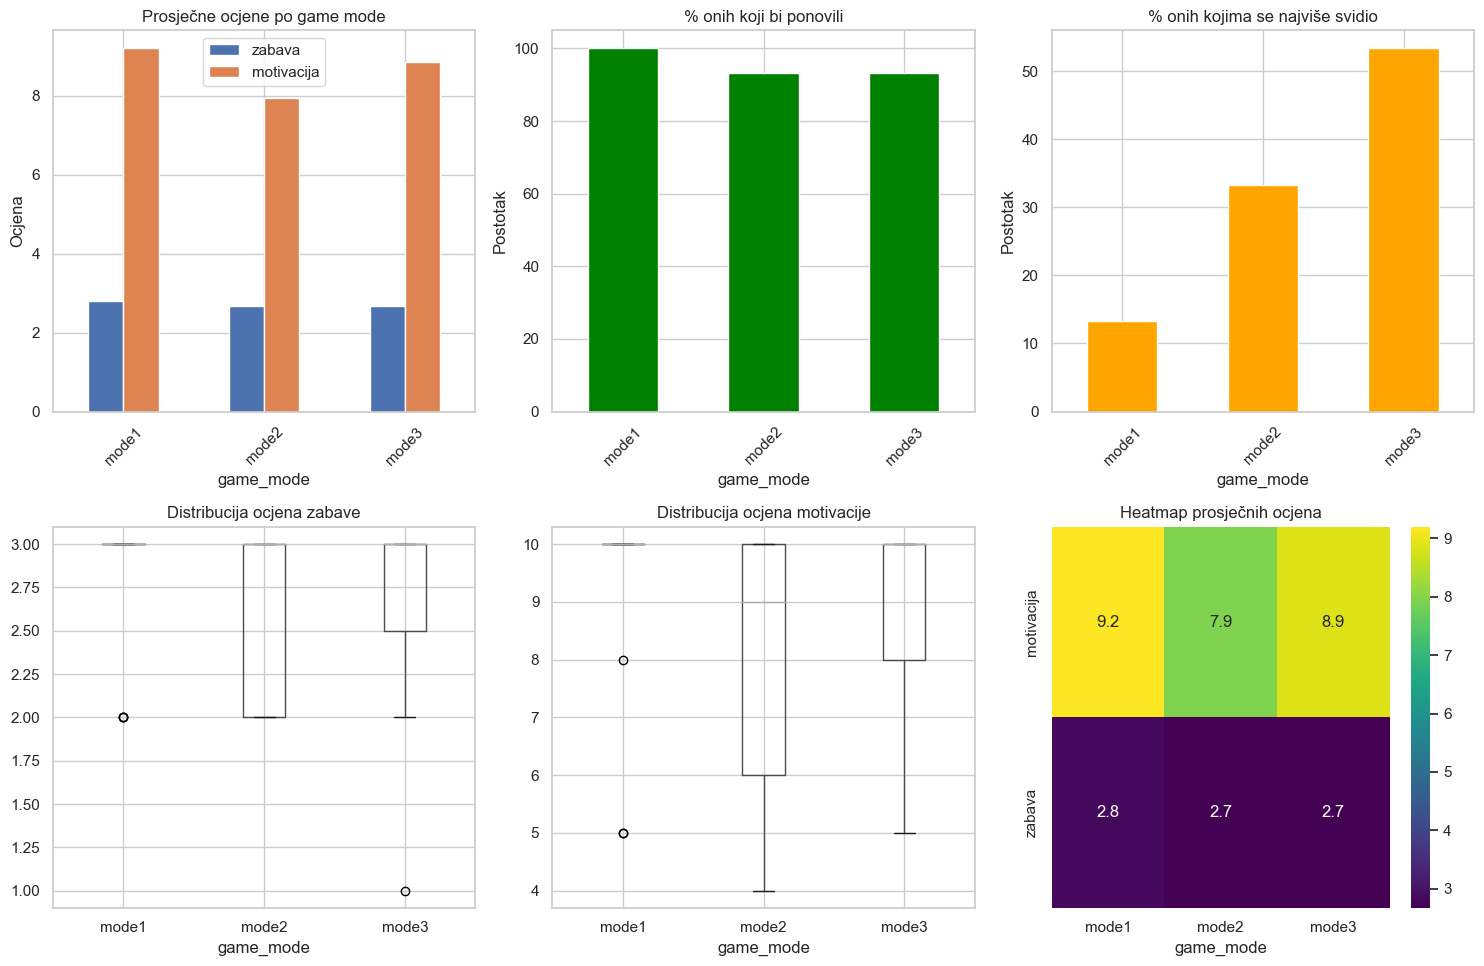

In [9]:
#ANKETA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Učitavanje podataka
df = pd.read_csv('anketa_filtered.csv')

print("=== OSNOVNE INFORMACIJE O PODACIMA ===")
print(f"Ukupan broj odgovora: {len(df)}")
print(f"Broj studenata: {df['student_id'].nunique()}")
print(f"Game modes: {df['game_mode'].unique()}")
print(f"Raspon datuma: {df['created_at'].min()} do {df['created_at'].max()}")

print("\n=== ANALIZA PO GAME MODES ===")

# Grupiranje po game_mode
game_mode_stats = df.groupby('game_mode').agg({
    'zabava': ['mean', 'std', 'min', 'max'],
    'motivacija': ['mean', 'std', 'min', 'max'],
    'ponovio_bi': lambda x: (x == True).sum() / len(x) * 100,  # postotak onih koji bi ponovili
    'najvise_svidjelo': lambda x: (x == True).sum() / len(x) * 100,  # postotak koji se najviše svidio
    'student_id': 'count'  # broj odgovora po mode-u
}).round(2)

game_mode_stats.columns = ['_'.join(col).strip() for col in game_mode_stats.columns]
print(game_mode_stats)

print("\n=== DETALJNE STATISTIKE PO GAME MODES ===")

for mode in df['game_mode'].unique():
    mode_data = df[df['game_mode'] == mode]
    print(f"\n--- {mode.upper()} ---")
    print(f"Broj odgovora: {len(mode_data)}")
    print(f"Zabava - prosjek: {mode_data['zabava'].mean():.2f}, medijan: {mode_data['zabava'].median()}")
    print(f"Motivacija - prosjek: {mode_data['motivacija'].mean():.2f}, medijan: {mode_data['motivacija'].median()}")
    print(f"Ponovio bi: {(mode_data['ponovio_bi'] == True).sum()}/{len(mode_data)} ({(mode_data['ponovio_bi'] == True).sum()/len(mode_data)*100:.1f}%)")
    print(f"Najviše se svidio: {(mode_data['najvise_svidjelo'] == True).sum()}/{len(mode_data)} ({(mode_data['najvise_svidjelo'] == True).sum()/len(mode_data)*100:.1f}%)")

print("\n=== RANGIRANJE GAME MODES ===")

# Rangiranje po različitim kriterijima
ranking_data = []
for mode in df['game_mode'].unique():
    mode_data = df[df['game_mode'] == mode]
    ranking_data.append({
        'game_mode': mode,
        'avg_zabava': mode_data['zabava'].mean(),
        'avg_motivacija': mode_data['motivacija'].mean(),
        'pct_ponovio_bi': (mode_data['ponovio_bi'] == True).sum() / len(mode_data) * 100,
        'pct_najvise_svidio': (mode_data['najvise_svidjelo'] == True).sum() / len(mode_data) * 100,
        'combined_score': (mode_data['zabava'].mean() + mode_data['motivacija'].mean()) / 2
    })

ranking_df = pd.DataFrame(ranking_data)

print("Rangiranje po prosječnoj zabavi:")
print(ranking_df.sort_values('avg_zabava', ascending=False)[['game_mode', 'avg_zabava']])

print("\nRangiranje po prosječnoj motivaciji:")
print(ranking_df.sort_values('avg_motivacija', ascending=False)[['game_mode', 'avg_motivacija']])

print("\nRangiranje po postotku onih koji bi ponovili:")
print(ranking_df.sort_values('pct_ponovio_bi', ascending=False)[['game_mode', 'pct_ponovio_bi']])

print("\nRangiranje po postotku onih kojima se najviše svidio:")
print(ranking_df.sort_values('pct_najvise_svidio', ascending=False)[['game_mode', 'pct_najvise_svidio']])

print("\nRangiranje po kombiniranom rezultatu (zabava + motivacija):")
print(ranking_df.sort_values('combined_score', ascending=False)[['game_mode', 'combined_score']])

print("\n=== ANALIZA PO STUDENTIMA ===")

# Provjera koji mode je najčešće označen kao "najviše se svidio"
#student_preferences = df[df['nejvise_svidjelo'] == True]['game_mode'].value_counts()
#print("Koje game modes su najčešće označeni kao 'najviše se svidio':")
#print(student_preferences)

print("\n=== KORELACIJSKA ANALIZA ===")

# Korelacije između varijabli po game modes
numeric_cols = ['zabava', 'motivacija']
correlation_matrix = df[numeric_cols].corr()
print("Korelacija između zabave i motivacije:")
print(correlation_matrix)

print("\n=== DODATNE STATISTIKE ===")

# Koliko studenata je ocijenjeno svaki mode
print("Broj jedinstvenih studenata po game mode:")
for mode in df['game_mode'].unique():
    unique_students = df[df['game_mode'] == mode]['student_id'].nunique()
    print(f"{mode}: {unique_students} studenata")

# Distribucija ocjena
print("\nDistribucija ocjena zabave:")
for mode in df['game_mode'].unique():
    mode_data = df[df['game_mode'] == mode]
    zabava_dist = mode_data['zabava'].value_counts().sort_index()
    print(f"{mode}: {dict(zabava_dist)}")

print("\nDistribucija ocjena motivacije:")
for mode in df['game_mode'].unique():
    mode_data = df[df['game_mode'] == mode]
    motivacija_dist = mode_data['motivacija'].value_counts().sort_index()
    print(f"{mode}: {dict(motivacija_dist)}")

print("\nDistribucija 'najviše se svidjelo':")
for mode in df['game_mode'].unique():
    mode_data = df[df['game_mode'] == mode]
    svidjelo_dist = mode_data['najvise_svidjelo'].value_counts()
    print(f"{mode}: {dict(svidjelo_dist)}")

# Kreiranje vizualizacija (opcionalno - trebate matplotlib)
try:
    plt.figure(figsize=(15, 10))
    
    # Subplot 1: Prosječne ocjene
    plt.subplot(2, 3, 1)
    avg_scores = df.groupby('game_mode')[['zabava', 'motivacija']].mean()
    avg_scores.plot(kind='bar', ax=plt.gca())
    plt.title('Prosječne ocjene po game mode')
    plt.ylabel('Ocjena')
    plt.xticks(rotation=45)
    
    # Subplot 2: Postotci "ponovio bi"
    plt.subplot(2, 3, 2)
    ponovio_pct = df.groupby('game_mode')['ponovio_bi'].apply(lambda x: (x == True).sum() / len(x) * 100)
    ponovio_pct.plot(kind='bar', color='green', ax=plt.gca())
    plt.title('% onih koji bi ponovili')
    plt.ylabel('Postotak')
    plt.xticks(rotation=45)
    
    # Subplot 3: Postotci "najviše se svidio"
    plt.subplot(2, 3, 3)
    svidio_pct = df.groupby('game_mode')['najvise_svidjelo'].apply(lambda x: (x == True).sum() / len(x) * 100)
    svidio_pct.plot(kind='bar', color='orange', ax=plt.gca())
    plt.title('% onih kojima se najviše svidio')
    plt.ylabel('Postotak')
    plt.xticks(rotation=45)
    
    # Subplot 4: Box plot zabave
    plt.subplot(2, 3, 4)
    df.boxplot(column='zabava', by='game_mode', ax=plt.gca())
    plt.title('Distribucija ocjena zabave')
    plt.suptitle('')
    
    # Subplot 5: Box plot motivacije
    plt.subplot(2, 3, 5)
    df.boxplot(column='motivacija', by='game_mode', ax=plt.gca())
    plt.title('Distribucija ocjena motivacije')
    plt.suptitle('')
    
    # Subplot 6: Heatmap korelacija
    plt.subplot(2, 3, 6)
    pivot_corr = df.pivot_table(values=['zabava', 'motivacija'], 
                                index='game_mode', 
                                aggfunc='mean')
    sns.heatmap(pivot_corr.T, annot=True, cmap='viridis', ax=plt.gca())
    plt.title('Heatmap prosječnih ocjena')
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Za vizualizacije trebate instalirati matplotlib i seaborn:")
    print("pip install matplotlib seaborn")

In [10]:
print("\n=== ALTERNATIVNI PRIKAZ DISTRIBUCIJA ===")

# Vizualni prikaz distribucija pomoću ASCII grafova
def create_ascii_bar(value, max_value, width=20):
    """Kreira ASCII bar graf"""
    if max_value == 0:
        return "▏" * 0
    bar_length = int((value / max_value) * width)
    return "█" * bar_length + "▒" * (width - bar_length)

# Distribucija zabave po game modes
print("\n📊 DISTRIBUCIJA ZABAVE (1-3 skala):")
for mode in sorted(df['game_mode'].unique()):
    mode_data = df[df['game_mode'] == mode]
    print(f"\n{mode.upper()}:")
    zabava_counts = mode_data['zabava'].value_counts().sort_index()
    max_count = max(zabava_counts.values) if len(zabava_counts) > 0 else 1
    
    for score in range(1, 4):  # 1, 2, 3
        count = zabava_counts.get(score, 0)
        percentage = (count / len(mode_data)) * 100
        bar = create_ascii_bar(count, max_count)
        print(f"  Ocjena {score}: {bar} {count:2d} ({percentage:4.1f}%)")

# Distribucija motivacije po game modes
print("\n🎯 DISTRIBUCIJA MOTIVACIJE (1-10 skala):")
for mode in sorted(df['game_mode'].unique()):
    mode_data = df[df['game_mode'] == mode]
    print(f"\n{mode.upper()}:")
    motivacija_counts = mode_data['motivacija'].value_counts().sort_index()
    max_count = max(motivacija_counts.values) if len(motivacija_counts) > 0 else 1
    
    for score in range(1, 11):  # 1-10
        count = motivacija_counts.get(score, 0)
        if count > 0:  # Prikaži samo ocjene koje postoje
            percentage = (count / len(mode_data)) * 100
            bar = create_ascii_bar(count, max_count)
            print(f"  Ocjena {score:2d}: {bar} {count:2d} ({percentage:4.1f}%)")

# Distribucija "ponovio bi"
print("\n🔄 DISTRIBUCIJA 'PONOVIO BI':")
for mode in sorted(df['game_mode'].unique()):
    mode_data = df[df['game_mode'] == mode]
    ponovio_counts = mode_data['ponovio_bi'].value_counts()
    total = len(mode_data)
    
    true_count = ponovio_counts.get(True, 0)
    false_count = ponovio_counts.get(False, 0)
    
    true_pct = (true_count / total) * 100
    false_pct = (false_count / total) * 100
    
    print(f"\n{mode.upper()}:")
    print(f"  DA:  {'█' * int(true_pct/5):<20} {true_count:2d} ({true_pct:4.1f}%)")
    print(f"  NE:  {'█' * int(false_pct/5):<20} {false_count:2d} ({false_pct:4.1f}%)")

# Distribucija "najviše se svidjelo" - FOKUS NA TRUE vrijednosti
print("\n⭐ DISTRIBUCIJA 'NAJVIŠE SE SVIDJELO' (fokus na TRUE):")
svidjelo_true_counts = {}
total_responses = {}

for mode in sorted(df['game_mode'].unique()):
    mode_data = df[df['game_mode'] == mode]
    svidjelo_counts = mode_data['najvise_svidjelo'].value_counts()
    
    true_count = svidjelo_counts.get(True, 0)
    total_count = len(mode_data)
    
    svidjelo_true_counts[mode] = true_count
    total_responses[mode] = total_count

# Sortiranje po broju TRUE odgovora
sorted_modes = sorted(svidjelo_true_counts.items(), key=lambda x: x[1], reverse=True)
max_true = max(svidjelo_true_counts.values()) if svidjelo_true_counts.values() else 1

print("\nRangiranje po broju 'TRUE' odgovora:")
for i, (mode, true_count) in enumerate(sorted_modes, 1):
    total = total_responses[mode]
    percentage = (true_count / total) * 100
    bar = create_ascii_bar(true_count, max_true, width=15)
    
    print(f"{i}. {mode.upper()}: {bar} {true_count}/{total} ({percentage:4.1f}%)")

# Sažetak najvažnijih rezultata
print("\n=== 🏆 SAŽETAK POBJEDNIKA ===")

# Najbolji po svakoj kategoriji
best_zabava = df.groupby('game_mode')['zabava'].mean().idxmax()
best_motivacija = df.groupby('game_mode')['motivacija'].mean().idxmax()
best_ponovio = df.groupby('game_mode')['ponovio_bi'].apply(lambda x: (x == True).sum() / len(x)).idxmax()
best_svidjelo = df.groupby('game_mode')['najvise_svidjelo'].apply(lambda x: (x == True).sum()).idxmax()

print(f"🎉 Najzabavniji: {best_zabava}")
print(f"💪 NajMotivacijski: {best_motivacija}")  
print(f"🔄 Najčešće bi ponovili: {best_ponovio}")
print(f"⭐ Najviše se svidio: {best_svidjelo}")

# Ukupni pobjednik (kombinacija svih faktora)
final_scores = {}
for mode in df['game_mode'].unique():
    mode_data = df[df['game_mode'] == mode]
    score = (
        mode_data['zabava'].mean() * 0.25 +
        mode_data['motivacija'].mean() * 0.1 * 0.25 +  # normalizacija na 0-3 skalu
        ((mode_data['ponovio_bi'] == True).sum() / len(mode_data)) * 3 * 0.25 +  # normalizacija na 0-3 skalu
        ((mode_data['najvise_svidjelo'] == True).sum() / len(mode_data)) * 3 * 0.25  # normalizacija na 0-3 skalu
    )
    final_scores[mode] = score
print(final_scores)
overall_winner = max(final_scores, key=final_scores.get)
print(f"🏆 UKUPNI POBJEDNIK: {overall_winner} (kombinirana ocjena: {final_scores[overall_winner]:.2f})")



=== ALTERNATIVNI PRIKAZ DISTRIBUCIJA ===

📊 DISTRIBUCIJA ZABAVE (1-3 skala):

MODE1:
  Ocjena 1: ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  0 ( 0.0%)
  Ocjena 2: █████▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  3 (20.0%)
  Ocjena 3: ████████████████████ 12 (80.0%)

MODE2:
  Ocjena 1: ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  0 ( 0.0%)
  Ocjena 2: ██████████▒▒▒▒▒▒▒▒▒▒  5 (33.3%)
  Ocjena 3: ████████████████████ 10 (66.7%)

MODE3:
  Ocjena 1: █▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  1 ( 6.7%)
  Ocjena 2: █████▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  3 (20.0%)
  Ocjena 3: ████████████████████ 11 (73.3%)

🎯 DISTRIBUCIJA MOTIVACIJE (1-10 skala):

MODE1:
  Ocjena  5: ███▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  2 (13.3%)
  Ocjena  8: █▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  1 ( 6.7%)
  Ocjena 10: ████████████████████ 12 (80.0%)

MODE2:
  Ocjena  4: ██▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  1 ( 6.7%)
  Ocjena  5: ██▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  1 ( 6.7%)
  Ocjena  6: ███████████▒▒▒▒▒▒▒▒▒  4 (26.7%)
  Ocjena  7: ██▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  1 ( 6.7%)
  Ocjena  9: ██▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  1 ( 6.7%)
  Ocjena 10: ████████████████████  7 (46.7%)

MODE3:
  Ocjena  5: ██▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

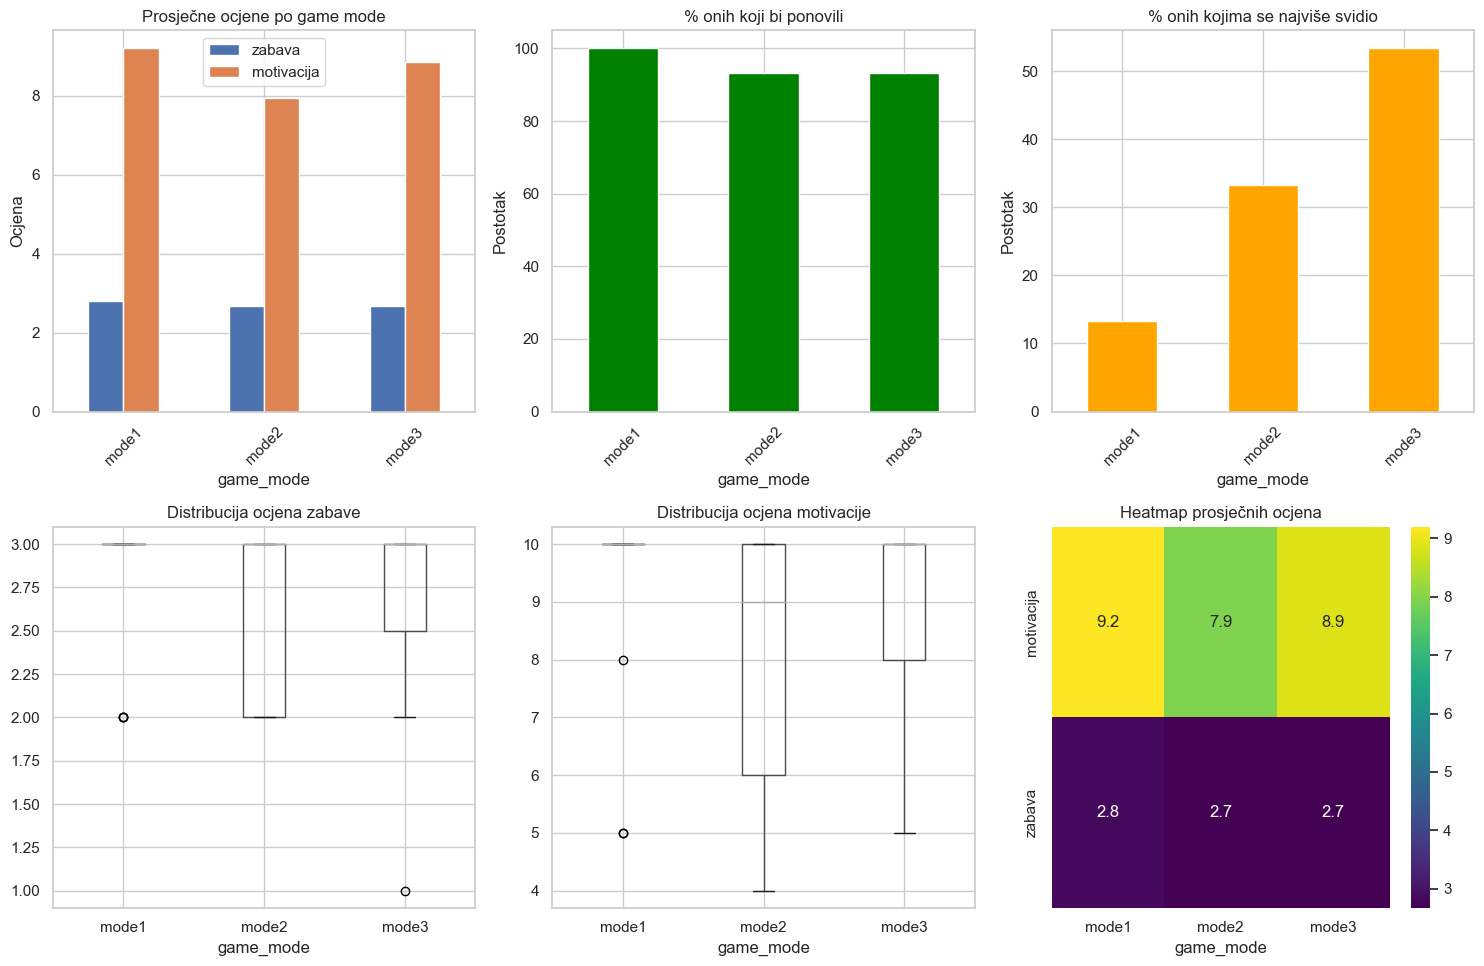

In [11]:
# Kreiranje vizualizacija (opcionalno - trebate matplotlib)
try:
    plt.figure(figsize=(15, 10))
    
    # Subplot 1: Prosječne ocjene
    plt.subplot(2, 3, 1)
    avg_scores = df.groupby('game_mode')[['zabava', 'motivacija']].mean()
    avg_scores.plot(kind='bar', ax=plt.gca())
    plt.title('Prosječne ocjene po game mode')
    plt.ylabel('Ocjena')
    plt.xticks(rotation=45)
    
    # Subplot 2: Postotci "ponovio bi"
    plt.subplot(2, 3, 2)
    ponovio_pct = df.groupby('game_mode')['ponovio_bi'].apply(lambda x: (x == True).sum() / len(x) * 100)
    ponovio_pct.plot(kind='bar', color='green', ax=plt.gca())
    plt.title('% onih koji bi ponovili')
    plt.ylabel('Postotak')
    plt.xticks(rotation=45)
    
    # Subplot 3: Postotci "najviše se svidio"
    plt.subplot(2, 3, 3)
    svidio_pct = df.groupby('game_mode')['najvise_svidjelo'].apply(lambda x: (x == True).sum() / len(x) * 100)
    svidio_pct.plot(kind='bar', color='orange', ax=plt.gca())
    plt.title('% onih kojima se najviše svidio')
    plt.ylabel('Postotak')
    plt.xticks(rotation=45)
    
    # Subplot 4: Box plot zabave
    plt.subplot(2, 3, 4)
    df.boxplot(column='zabava', by='game_mode', ax=plt.gca())
    plt.title('Distribucija ocjena zabave')
    plt.suptitle('')
    
    # Subplot 5: Box plot motivacije
    plt.subplot(2, 3, 5)
    df.boxplot(column='motivacija', by='game_mode', ax=plt.gca())
    plt.title('Distribucija ocjena motivacije')
    plt.suptitle('')
    
    # Subplot 6: Heatmap korelacija
    plt.subplot(2, 3, 6)
    pivot_corr = df.pivot_table(values=['zabava', 'motivacija'], 
                                index='game_mode', 
                                aggfunc='mean')
    sns.heatmap(pivot_corr.T, annot=True, cmap='viridis', ax=plt.gca())
    plt.title('Heatmap prosječnih ocjena')
    
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Za vizualizacije trebate instalirati matplotlib i seaborn:")
    print("pip install matplotlib seaborn")

=== Summary per Game Mode ===
          time_taken        correct_answers       wrong_answers         \
                mean    std            mean   std          mean    std   
game_mode                                                                
computer       44.54  38.65           11.63  3.05         16.13   7.68   
practice       89.91  44.76           10.00  0.00          6.55   6.23   
pvp           102.08  27.92           15.19  7.61         19.84  12.48   

          total_questions        accuracy       attempts_per_question        \
                     mean    std     mean   std                  mean   std   
game_mode                                                                     
computer            14.81   4.93     0.45  0.17                  1.98  0.75   
practice            10.00   0.00     0.68  0.21                  1.65  0.62   
pvp                 31.72  12.85     0.46  0.18                  1.11  0.50   

          wrong_attempts_per_question        
    

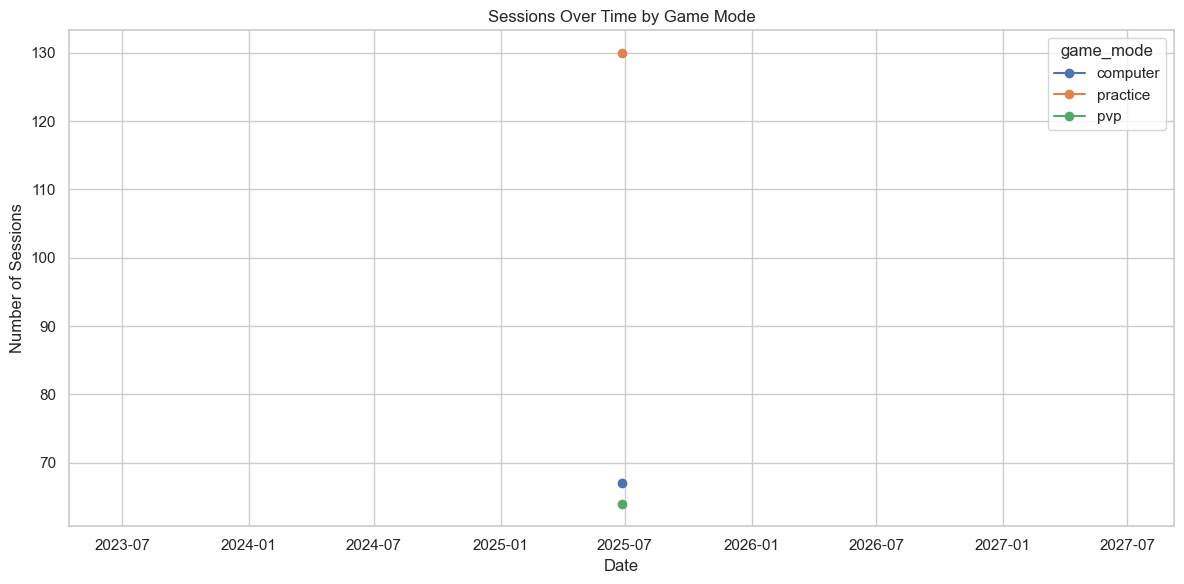


=== Top 5 Students by Accuracy ===
           time_taken        correct_answers       wrong_answers         \
                 mean    std            mean   std          mean    std   
student_id                                                                
39             175.56  61.72            9.00  1.80          1.22   0.97   
2              120.00   0.00           15.00  5.79          4.00   2.24   
36             101.08  34.96           12.62  3.48          9.23   9.35   
30              55.77  27.46           13.69  8.52         14.92  16.66   
41             100.17  26.19           12.58  3.96          9.75   7.77   
43             101.44  26.71           15.25  6.71         13.06  11.72   
49              65.81  41.61           12.14  3.80         13.57  12.28   
42              67.58  35.74           10.89  2.13         11.00   8.30   
46              84.07  26.95           10.50  2.85         11.86   9.96   
48             101.56  38.12           10.50  4.20         12.78

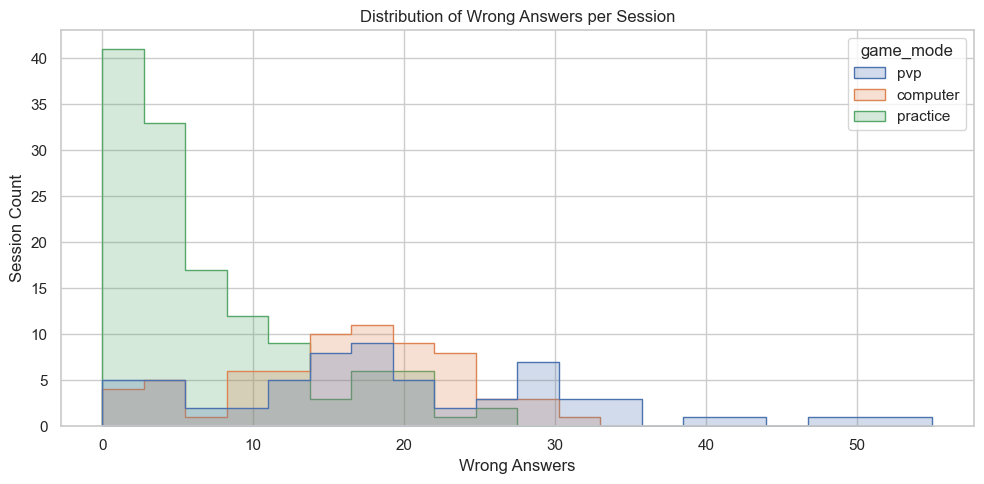

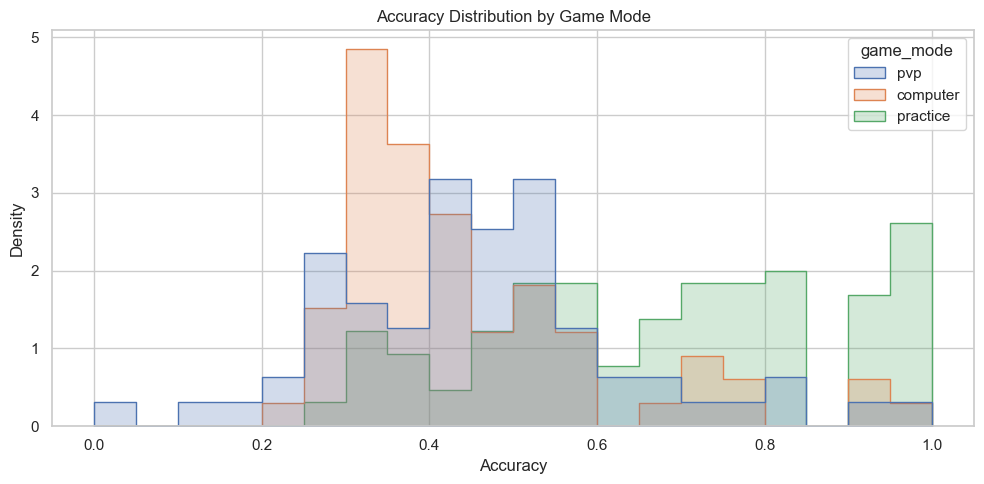

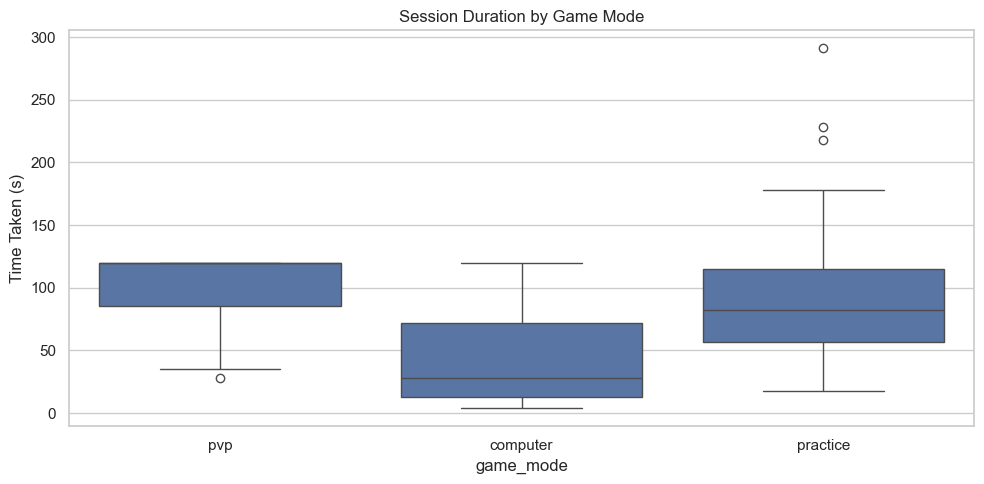

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("c.csv")

# Prepare and compute metrics
df["total_attempts"] = df["correct_answers"] + df["wrong_answers"]
df["accuracy"] = df["correct_answers"] / df["total_attempts"]
df["attempts_per_question"] = df["total_attempts"] / df["total_questions"]
df["wrong_attempts_per_question"] = df["wrong_answers"] / df["total_questions"]
df["created_at"] = pd.to_datetime(df["created_at"])
df["date"] = df["created_at"].dt.date

# -----------------------------
# 1. Game mode level analysis
# -----------------------------
mode_summary = df.groupby("game_mode").agg({
    "time_taken": ["mean", "std"],
    "correct_answers": ["mean", "std"],
    "wrong_answers": ["mean", "std"],
    "total_questions": ["mean", "std"],
    "accuracy": ["mean", "std"],
    "attempts_per_question": ["mean", "std"],
    "wrong_attempts_per_question": ["mean", "std"]
}).round(2)

print("=== Summary per Game Mode ===")
print(mode_summary)

# -----------------------------
# 2. Session counts
# -----------------------------
print("\n=== Session Counts by Mode ===")
print(df["game_mode"].value_counts())

print("\n=== Session Counts by Topic ===")
print(df["topic_id"].value_counts())

# -----------------------------
# 3. Timeline analysis
# -----------------------------
timeline = df.groupby(["date", "game_mode"]).size().unstack(fill_value=0)
timeline.plot(figsize=(12, 6), marker="o")
plt.title("Sessions Over Time by Game Mode")
plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Student-level analysis
# -----------------------------
student_summary = df.groupby("student_id").agg({
    "time_taken": ["mean", "std"],
    "correct_answers": ["mean", "std"],
    "wrong_answers": ["mean", "std"],
    "total_questions": ["mean", "std"],
    "accuracy": ["mean", "std"],
    "attempts_per_question": ["mean", "std"],
    "wrong_attempts_per_question": ["mean", "std"]
}).round(2)

student_summary_sorted = student_summary.sort_values(("accuracy", "mean"), ascending=False)

print("\n=== Top 5 Students by Accuracy ===")
print(student_summary_sorted)

# -----------------------------
# 5. Visualizations
# -----------------------------
# Histogram of wrong answers per session
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="wrong_answers", hue="game_mode", bins=20, element="step", stat="count", common_norm=False)
plt.title("Distribution of Wrong Answers per Session")
plt.xlabel("Wrong Answers")
plt.ylabel("Session Count")
plt.tight_layout()
plt.show()

# Histogram of accuracy
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="accuracy", hue="game_mode", bins=20, element="step", stat="density", common_norm=False)
plt.title("Accuracy Distribution by Game Mode")
plt.xlabel("Accuracy")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Boxplot of time taken
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="game_mode", y="time_taken")
plt.title("Session Duration by Game Mode")
plt.ylabel("Time Taken (s)")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

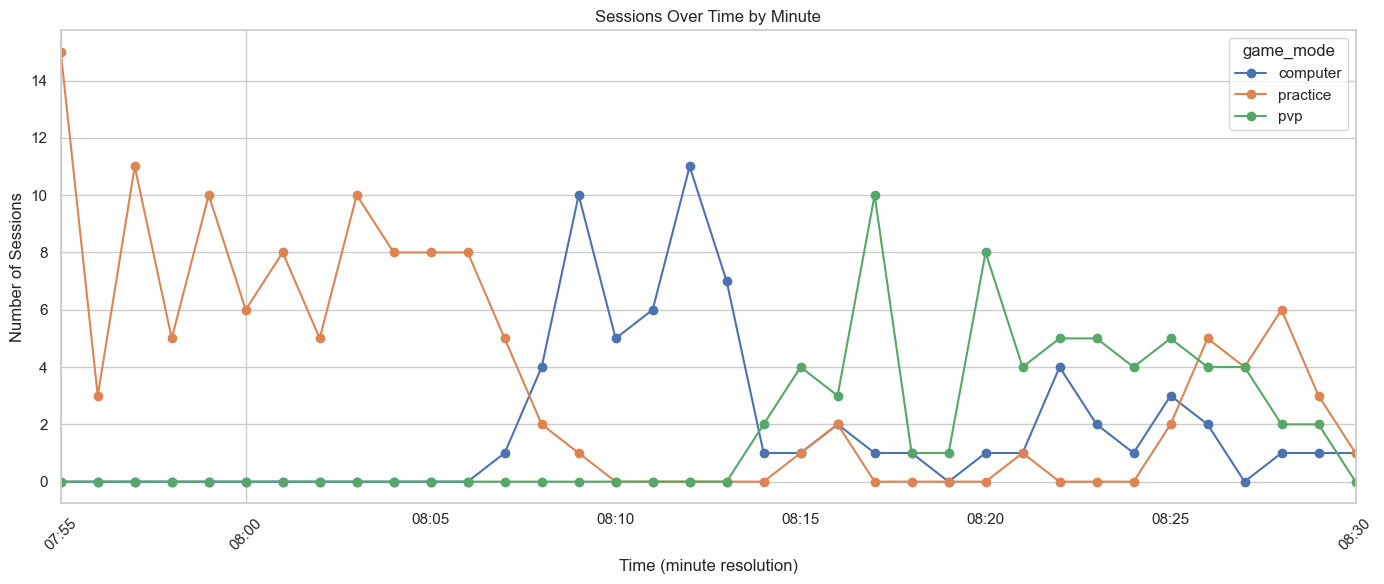

In [10]:
# Group sessions by minute instead of date
df["minute"] = df["created_at"].dt.floor("T")  # floor to the nearest minute

# Count sessions per minute per mode
minute_timeline = df.groupby(["minute", "game_mode"]).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
ax = minute_timeline.plot(marker='o', figsize=(14, 6))
plt.title("Sessions Over Time by Minute")
plt.xlabel("Time (minute resolution)")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save as image
plt.savefig("sessions_over_time_by_minute.png", dpi=300)

# Show plot
plt.show()

#save as picture



In [ ]:
plt.savefig("sessions_over_time_by_minute.png")

savefig(fname, dpi='figure', format=None)


<Figure size 640x480 with 0 Axes>

In [11]:
# Mapping of student IDs to names
id_to_name = {
    30: "josip",
    36: "marie",
    37: "marko",
    38: "melani",
    39: "leni",
    40: "natanijel",
    41: "anatinka",
    42: "rafael",
    43: "sven",
    44: "emily",
    45: "jana",
    46: "alen",
    47: "lucija",
    48: "azra",
    49: "roko",
    50: "ana"
}

# Scores from second image (name: score)
name_to_score = {
    "roko": 1168,
    "leni": 1114,
    "josip": 1091,
    "erna": 979,
    "emar": 948,
    "azra": 946,
    "marie": 944,
    "anatinka": 926,
    "melani": 905,
    "gloria": 903,
    "marko": 902,
    "emak": 874,
    "miki": 860,
    "rafael": 856,
    "jana": 838,
    "mila": 832,
    "dominik": 831,
    "roko2": 830,
    "aurora": 822,
    "sven": 820,
    "ian": 813,
    "luka": 807,
    "lucija": 801,
    "ela": 790,
    "natanijel": 788,
    "ana": 788,
    "alen": 638
}

# Merge only those who are in both datasets
merged = []
for student_id, name in id_to_name.items():
    if name in name_to_score:
        merged.append((student_id, name, name_to_score[name]))

# Sort by score descending
merged.sort(key=lambda x: x[2], reverse=True)

# Display the results
import pandas as pd
df = pd.DataFrame(merged, columns=["Student ID", "Name", "Score"])
print(df)


    Student ID       Name  Score
0           49       roko   1168
1           39       leni   1114
2           30      josip   1091
3           48       azra    946
4           36      marie    944
5           41   anatinka    926
6           38     melani    905
7           37      marko    902
8           42     rafael    856
9           45       jana    838
10          43       sven    820
11          47     lucija    801
12          40  natanijel    788
13          50        ana    788
14          46       alen    638


In [13]:
import pandas as pd
from scipy.stats import spearmanr

# Poveznica imena s ID-jevima
student_id_name = {
    30: "josip",
    36: "marie",
    37: "marko",
    38: "melani",
    39: "leni",
    40: "natanijel",
    41: "anatinka",
    42: "rafael",
    43: "sven",
    44: "emily",       # nije u app podacima
    45: "jana",
    46: "alen",
    47: "lucija",
    48: "azra",
    49: "roko",
    50: "ana"
}

# Profini rangovi — samo učenici iz aplikacije (ignoriši one koji nisu)
profa_math_ids = [30, 49, 43, 38, 39, 36, 50, 41, 42, 37, 46, 47, 48, 40, 45]
profa_pid_ids  = [30, 49, 50, 41, 43, 46, 42, 36, 39, 38, 37, 47, 48, 45, 40]

profa_math = [student_id_name[i] for i in profa_math_ids if i in student_id_name]
profa_pid = [student_id_name[i] for i in profa_pid_ids if i in student_id_name]

# Rangovi iz aplikacije
scores1 = {
    "roko": 1168,
    "leni": 1114,
    "josip": 1091,
    "azra": 946,
    "marie": 944,
    "anatinka": 926,
    "melani": 905,
    "marko": 902,
    "rafael": 856,
    "jana": 838,
    "sven": 820,
    "lucija": 801,
    "natanijel": 788,
    "ana": 788,
    "alen": 638
}

scores2 = {
    "roko": 1087,
    "marie": 1045,
    "sven": 1043,
    "rafael": 993,
    "leni": 976,
    "josip": 935,
    "natanijel": 897,
    "marko": 887,
    "alen": 881,
    "lucija": 869,
    "melani": 863,
    "anatinka": 843,
    "jana": 826,
    "azra": 811,
    "ana": 489
}

# Rang lista aplikacije po vrijednosti (score1 i score2)
app_math_ranked = sorted(scores1.items(), key=lambda x: -x[1])
app_pid_ranked = sorted(scores2.items(), key=lambda x: -x[1])

# Mapiranje imena na njihov rang
math_app_ranks = {name: i+1 for i, (name, _) in enumerate(app_math_ranked)}
pid_app_ranks = {name: i+1 for i, (name, _) in enumerate(app_pid_ranked)}

# Kreiraj liste rangova za učenike koje ima i profa i aplikacija
def extract_ranks(name_list, rank_dict):
    return [rank_dict[name] for name in name_list if name in rank_dict]

math_profa_ranks = list(range(1, len(profa_math)+1))
math_app_ranks_list = extract_ranks(profa_math, math_app_ranks)
print(f"Matematika profa rangovi: {math_profa_ranks}")
print(f"Matematika app rangovi: {math_app_ranks_list}")

pid_profa_ranks = list(range(1, len(profa_pid)+1))
pid_app_ranks_list = extract_ranks(profa_pid, pid_app_ranks)
print(f"Priroda i društvo profa rangovi: {pid_profa_ranks}")
print(f"Priroda i društvo app rangovi: {pid_app_ranks_list}")
# Spearman korelacija
corr_math, _ = spearmanr(math_profa_ranks, math_app_ranks_list)
corr_pid, _ = spearmanr(pid_profa_ranks, pid_app_ranks_list)

print(f"📊 Spearman korelacija (Matematika): {corr_math:.3f}")
print(f"📊 Spearman korelacija (Priroda i društvo): {corr_pid:.3f}")


Matematika profa rangovi: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Matematika app rangovi: [3, 1, 11, 7, 2, 5, 14, 6, 9, 8, 15, 12, 4, 13, 10]
Priroda i društvo profa rangovi: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Priroda i društvo app rangovi: [6, 1, 15, 12, 3, 9, 4, 2, 5, 11, 8, 10, 14, 13, 7]
📊 Spearman korelacija (Matematika): 0.521
📊 Spearman korelacija (Priroda i društvo): 0.307


In [21]:
from scipy.stats import spearmanr

# Profesorove grupe
profa_groups_raw = [
    (1, 30), (1, 49), (2, 43), (2, 42), (3, 39), (3, 38), (4, 41), (5, 36),
    (5, 50), (6, 37), (6, 46), (7, 47), (8, 48), (8, 44), (9, 40), (9, 45)
]

# Naše grupe
our_groups = [
    (1, 49), (1, 39), (2, 30), (2, 48), (3, 47), (3, 36),
    (4, 41), (5, 38), (5, 37), (6, 42), (6, 43), (7, 45),
    (8, 40), (9, 46), (9, 50)
]

# Kreiraj DataFrame i spoji po ID-u
df_profa = pd.DataFrame(profa_groups_raw, columns=["profa_group", "id"])
df_our = pd.DataFrame(our_groups, columns=["our_group", "id"])

# Merge i izračun Spearmanovog koeficijenta
df_merged = df_profa.merge(df_our, on="id", how="inner")
spearman_corr, p_value = spearmanr(df_merged["profa_group"], df_merged["our_group"])

df_merged.sort_values("profa_group"), spearman_corr, p_value


(    profa_group  id  our_group
 0             1  30          2
 1             1  49          1
 2             2  43          6
 3             2  42          6
 4             3  39          1
 5             3  38          5
 6             4  41          4
 7             5  36          3
 8             5  50          9
 9             6  37          5
 10            6  46          9
 11            7  47          3
 12            8  48          2
 13            9  40          8
 14            9  45          7,
 0.3989169675090253,
 0.14076996358921903)

In [22]:
from scipy.stats import spearmanr

# Profesorove grupe
profa_groups_raw = [
    (1, 30), (1, 49), (2, 43), (2, 42), (3, 39), (3, 38), (4, 41), (5, 36),
    (5, 50), (6, 37), (6, 46), (7, 47), (8, 48), (8, 44), (9, 40), (9, 45)
]

# Naše grupe  ---sada prema accuarcyu 

our_groups = [
    (1, 39), (1, 36), (2, 30), (2, 41), (3, 43), (3, 49),
    (4, 42), (5, 46), (5, 48), (6, 37), (6, 40), (7, 38),
    (8, 45), (9, 47), (9, 50)
]

# Kreiraj DataFrame i spoji po ID-u
df_profa = pd.DataFrame(profa_groups_raw, columns=["profa_group", "id"])
df_our = pd.DataFrame(our_groups, columns=["our_group", "id"])

# Merge i izračun Spearmanovog koeficijenta
df_merged = df_profa.merge(df_our, on="id", how="inner")
spearman_corr, p_value = spearmanr(df_merged["profa_group"], df_merged["our_group"])

df_merged.sort_values("profa_group"), spearman_corr, p_value

(    profa_group  id  our_group
 0             1  30          2
 1             1  49          3
 2             2  43          3
 3             2  42          4
 4             3  39          1
 5             3  38          7
 6             4  41          2
 7             5  36          1
 8             5  50          9
 9             6  37          6
 10            6  46          5
 11            7  47          9
 12            8  48          5
 13            9  40          6
 14            9  45          8,
 0.5658844765342961,
 0.02788859999159604)